In [5]:
import requests
import matplotlib.pyplot as plt
import pandas as pd
from io import StringIO
import sqlite3
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup

url = 'https://en.wikipedia.org/wiki/List_of_most-streamed_songs_on_Spotify'
response = requests.get(url)

html_content = response.text  # This stores the scraped HTML text


In [6]:



# Parse the HTML content
soup = BeautifulSoup(html_content, 'html.parser')

# Extract the tables from the page using pandas
tables = pd.read_html(html_content)

# The table of interest is typically the first one, so we can load it as a DataFrame
df = tables[0]

/tmp/ipykernel_2893/2909264141.py:5: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(html_content)


In [7]:
print(df['Streams (billions)'].unique())


['4.815' '4.334' '3.884' '3.864' '3.854' '3.794' '3.736' '3.612' '3.534'
 '3.410' '3.409' '3.364' '3.288' '3.250' '3.244' '3.239' '3.164' '3.129'
 '3.073' '3.006' '2.998' '2.996' '2.990' '2.986' '2.946' '2.936' '2.909'
 '2.903' '2.869' '2.868' '2.853' '2.814' '2.805' '2.777' '2.760' '2.753'
 '2.752' '2.745' '2.722' '2.719' '2.716' '2.710' '2.697' '2.657' '2.639'
 '2.632' '2.631' '2.622' '2.617' '2.616' '2.613' '2.610' '2.600' '2.567'
 '2.557' '2.539' '2.537' '2.534' '2.518' '2.516' '2.488' '2.482' '2.479'
 '2.475' '2.466' '2.438' '2.414' '2.413' '2.392' '2.388' '2.385' '2.380'
 '2.374' '2.361' '2.357' '2.354' '2.341' '2.334' '2.331' '2.330' '2.321'
 '2.317' '2.307' '2.305' '2.302' '2.301' '2.299' '2.293' '2.290' '2.283'
 '2.276' '2.271' '2.250' 'As of 30 April 2025']


In [8]:
# Remove any leading/trailing spaces in column names
df.columns = df.columns.str.strip()

# Remove rows where 'Streams (billions)' is empty or NaN
df = df[df['Streams (billions)'].notna()]

# Clean 'Streams (billions)' by removing any non-numeric characters and convert to float
df['Streams (billions)'] = df['Streams (billions)'].replace(regex=r'[^\d.]', value='').astype(float)

# Drop rows that still contain NaN values in 'Streams (billions)'
df.dropna(subset=['Streams (billions)'], inplace=True)

# Reset index after cleaning
df.reset_index(drop=True, inplace=True)

# Display the cleaned DataFrame
df.head()


,Rank,Song,Artist(s),Streams (billions),Release date,Ref.
0,1,"""Blinding Lights""",The Weeknd,4.815,29 November 2019,[2]
1,2,"""Shape of You""",Ed Sheeran,4.334,6 January 2017,[3]
2,3,"""Someone You Loved""",Lewis Capaldi,3.884,8 November 2018,[4]
3,4,"""Starboy""",The Weeknd and Daft Punk,3.864,21 September 2016,[5]
4,5,"""As It Was""",Harry Styles,3.854,1 April 2022,[6]


In [14]:
print(df['Streams (billions)'].unique())


[4.81500e+00 4.33400e+00 3.88400e+00 3.86400e+00 3.85400e+00 3.79400e+00
 3.73600e+00 3.61200e+00 3.53400e+00 3.41000e+00 3.40900e+00 3.36400e+00
 3.28800e+00 3.25000e+00 3.24400e+00 3.23900e+00 3.16400e+00 3.12900e+00
 3.07300e+00 3.00600e+00 2.99800e+00 2.99600e+00 2.99000e+00 2.98600e+00
 2.94600e+00 2.93600e+00 2.90900e+00 2.90300e+00 2.86900e+00 2.86800e+00
 2.85300e+00 2.81400e+00 2.80500e+00 2.77700e+00 2.76000e+00 2.75300e+00
 2.75200e+00 2.74500e+00 2.72200e+00 2.71900e+00 2.71600e+00 2.71000e+00
 2.69700e+00 2.65700e+00 2.63900e+00 2.63200e+00 2.63100e+00 2.62200e+00
 2.61700e+00 2.61600e+00 2.61300e+00 2.61000e+00 2.60000e+00 2.56700e+00
 2.55700e+00 2.53900e+00 2.53700e+00 2.53400e+00 2.51800e+00 2.51600e+00
 2.48800e+00 2.48200e+00 2.47900e+00 2.47500e+00 2.46600e+00 2.43800e+00
 2.41400e+00 2.41300e+00 2.39200e+00 2.38800e+00 2.38500e+00 2.38000e+00
 2.37400e+00 2.36100e+00 2.35700e+00 2.35400e+00 2.34100e+00 2.33400e+00
 2.33100e+00 2.33000e+00 2.32100e+00 2.31700e+00 2.

In [15]:
print(df.columns)


Index(['Rank', 'Song', 'Artist(s)', 'Streams (billions)', 'Release date',
       'Ref.'],
      dtype='object')


In [16]:
import sqlite3

# Connect to SQLite database (it will be created if it doesn't exist)
conn = sqlite3.connect('spotify_songs.db')

# Create a table for the data (if it doesn't exist)
conn.execute('''CREATE TABLE IF NOT EXISTS songs
                (Rank INTEGER, Song TEXT, Artist TEXT, Streams REAL, Release_date TEXT, Ref TEXT)''')

# Insert the cleaned data into the database
df.to_sql('songs', conn, if_exists='replace', index=False)

# Commit the changes and close the connection
conn.commit()
conn.close()


In [17]:
conn = sqlite3.connect('spotify_songs.db')
cursor = conn.cursor()

# Check the table schema to see the column names
cursor.execute("PRAGMA table_info(songs)")
columns = cursor.fetchall()
conn.close()

# Print the columns to verify
for column in columns:
    print(column)


(0, 'Rank', 'TEXT', 0, None, 0)
(1, 'Song', 'TEXT', 0, None, 0)
(2, 'Artist(s)', 'TEXT', 0, None, 0)
(3, 'Streams (billions)', 'REAL', 0, None, 0)
(4, 'Release date', 'TEXT', 0, None, 0)
(5, 'Ref.', 'TEXT', 0, None, 0)


In [18]:
# Reopen the database and load the data
conn = sqlite3.connect('spotify_songs.db')
df_sql = pd.read_sql_query("SELECT * FROM songs", conn)
conn.close()

# Check for any invalid characters or unexpected values in the 'Streams (billions)' column
print("Unique values in 'Streams (billions)':")
print(df_sql['Streams (billions)'].unique())

# Check for any rows that may have problematic values
invalid_values = df_sql[df_sql['Streams (billions)'].apply(lambda x: isinstance(x, str) and not x.replace('.', '', 1).isdigit())]
print("Invalid values in 'Streams (billions)':")
print(invalid_values)

# Convert 'Streams (billions)' to numeric, forcing errors to NaN
df_sql['Streams (billions)'] = pd.to_numeric(df_sql['Streams (billions)'], errors='coerce')

# Check for NaN values after conversion
print("Rows with NaN 'Streams (billions)':")
print(df_sql[df_sql['Streams (billions)'].isna()])

# Drop rows with NaN values in 'Streams (billions)' for plotting
df_sql_clean = df_sql.dropna(subset=['Streams (billions)'])

# Check the data types of columns after cleaning
print("Data types after cleaning:")
print(df_sql_clean.dtypes)

# Verify the first few rows of the cleaned data
print("Cleaned data (top rows):")
print(df_sql_clean.head())

Unique values in 'Streams (billions)':
[4.81500e+00 4.33400e+00 3.88400e+00 3.86400e+00 3.85400e+00 3.79400e+00
 3.73600e+00 3.61200e+00 3.53400e+00 3.41000e+00 3.40900e+00 3.36400e+00
 3.28800e+00 3.25000e+00 3.24400e+00 3.23900e+00 3.16400e+00 3.12900e+00
 3.07300e+00 3.00600e+00 2.99800e+00 2.99600e+00 2.99000e+00 2.98600e+00
 2.94600e+00 2.93600e+00 2.90900e+00 2.90300e+00 2.86900e+00 2.86800e+00
 2.85300e+00 2.81400e+00 2.80500e+00 2.77700e+00 2.76000e+00 2.75300e+00
 2.75200e+00 2.74500e+00 2.72200e+00 2.71900e+00 2.71600e+00 2.71000e+00
 2.69700e+00 2.65700e+00 2.63900e+00 2.63200e+00 2.63100e+00 2.62200e+00
 2.61700e+00 2.61600e+00 2.61300e+00 2.61000e+00 2.60000e+00 2.56700e+00
 2.55700e+00 2.53900e+00 2.53700e+00 2.53400e+00 2.51800e+00 2.51600e+00
 2.48800e+00 2.48200e+00 2.47900e+00 2.47500e+00 2.46600e+00 2.43800e+00
 2.41400e+00 2.41300e+00 2.39200e+00 2.38800e+00 2.38500e+00 2.38000e+00
 2.37400e+00 2.36100e+00 2.35700e+00 2.35400e+00 2.34100e+00 2.33400e+00
 2.33100e+00

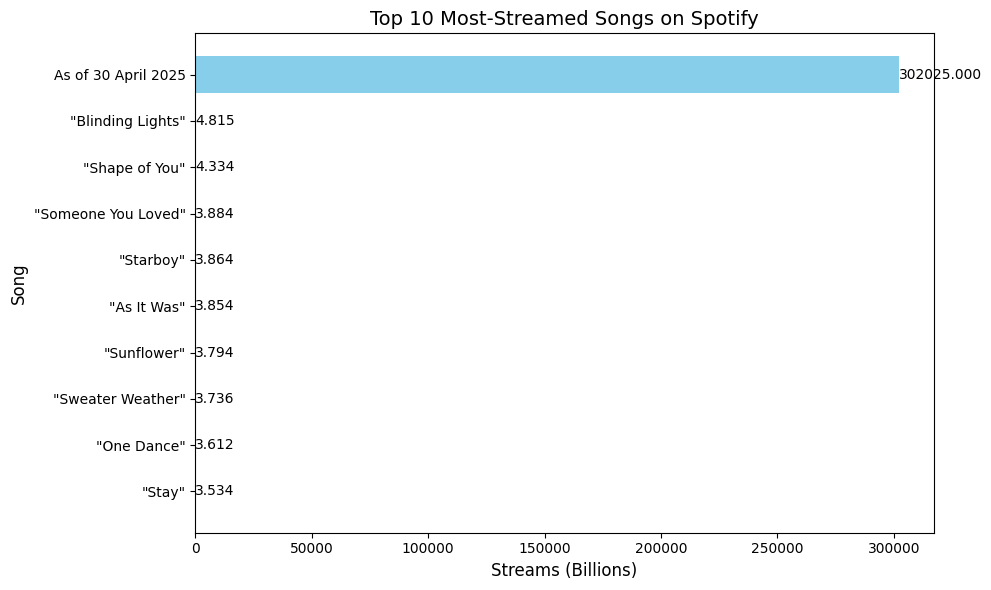

In [19]:
import matplotlib.pyplot as plt
import sqlite3
import pandas as pd

# Reopen the database and load the data
conn = sqlite3.connect('spotify_songs.db')
df_sql = pd.read_sql_query("SELECT * FROM songs", conn)
conn.close()

# Convert 'Streams (billions)' to numeric, forcing errors to NaN
df_sql['Streams (billions)'] = pd.to_numeric(df_sql['Streams (billions)'], errors='coerce')

# Remove rows where 'Streams (billions)' is NaN (like the "As of 30 April 2025" row)
df_sql_clean = df_sql.dropna(subset=['Streams (billions)'])

# Top 10 most-streamed songs
top_10 = df_sql_clean.sort_values(by='Streams (billions)', ascending=False).head(10)

# Plot the top 10 most-streamed songs
plt.figure(figsize=(10, 6))
plt.barh(top_10['Song'], top_10['Streams (billions)'], color='skyblue')

# Formatting for better visualization
plt.xlabel('Streams (Billions)', fontsize=12)
plt.ylabel('Song', fontsize=12)
plt.title('Top 10 Most-Streamed Songs on Spotify', fontsize=14)
plt.gca().invert_yaxis()  # Invert y-axis to display the top song at the top

# Add value labels on the bars for clarity
for index, value in enumerate(top_10['Streams (billions)']):
    plt.text(value, index, f'{value:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()


I keeeep getting it to post ALL of the streams in a single row, I am having trouble removing it